In [27]:
#!pip install darts

In [28]:
import numpy as np
import pandas as pd
from darts import TimeSeries
import matplotlib.pyplot as plt
import statsmodels.api as sm


$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \ldots + \phi_p X_{t-p} + \varepsilon_t$$


El modelo ARMA(p,q) se define generalmente como:

$$
X_t = c + \varepsilon_t + \sum_{i=1}^{p} \phi_i X_{t-i} + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

Donde $ \varepsilon_t $ es un ruido blanco.

Cuando implementamos este modelo usando arma\_generate\_sample, los coeficientes AR y MA se definen de la siguiente manera:

$$
AR = [1, -\phi_1, -\phi_2, \ldots, -\phi_p]
$$

$$
MA = [1, \theta_1, \theta_2, \ldots, \theta_q]
$$

El primer término de cada lista (el "1") es simplemente una convención en statsmodels y no se refiere a un coeficiente real en la ecuación ARMA.

Por eso, para un modelo ARMA(0,2) (que es esencialmente un modelo MA(2) sin términos AR), definimos ar = [1] (sin términos AR) y ma con tres valores, donde el primero es 1 y los otros dos son los coeficientes MA.


In [29]:
np.random.seed(0)
#Entonces acá estamos simulando una serie temporal autoregresiva de orden 2 (AR(2))
ar = np.array([1, 0.7, -0.2])  # AR terms (Changed from the MA terms -> coeficientes del modelo AR(2).
ma = np.array([1])  # No MA terms
simulated_data_ar2 = sm.tsa.arma_generate_sample(ar=ar, ma=ma, nsample=1000)


OJO: en statsmodels, el signo del término autoregresivo se invierte con respecto a la notación matemática habitual.

Como el código que dieron tiene [1, 0.7, -0.2], significa que el modelo simulado será:

𝑋𝑡=−0.7𝑋𝑡−1+0.2𝑋𝑡−2+𝜀𝑡 #LA FORMULA TRADICIONAL CAMBIA EL SIGNO DE LOS NÚMEROS DEL VECTOR ar

📌 En resumen:

El primer “1” es el coeficiente base, siempre está.

Los siguientes valores representan los coeficientes autoregresivos con signo opuesto a la fórmula tradicional.

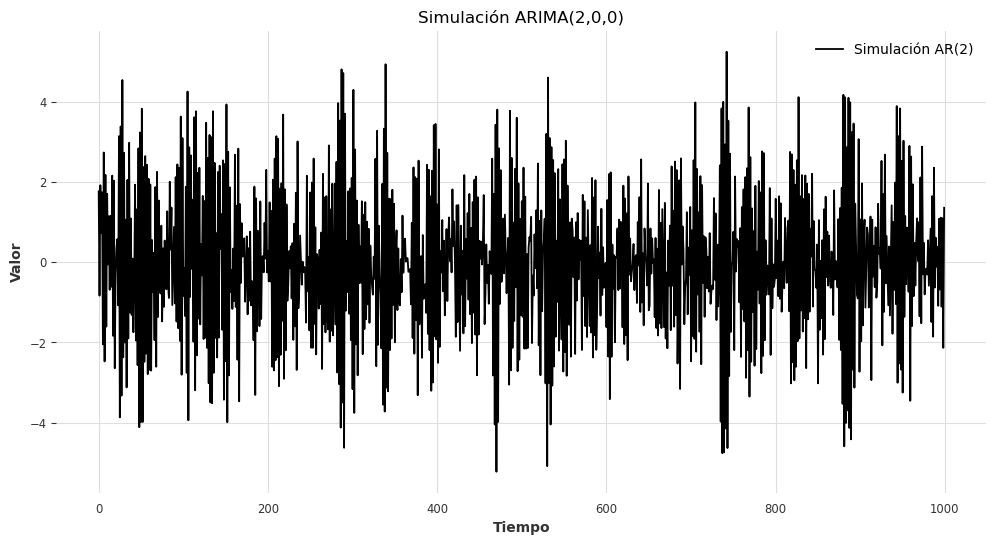

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(simulated_data_ar2, label='Simulación AR(2)')
plt.legend()
plt.title("Simulación ARIMA(2,0,0)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

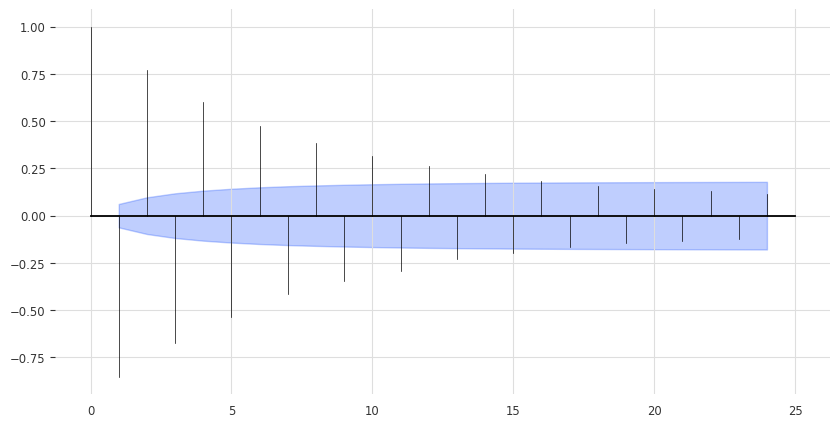

In [31]:
time_index = pd.date_range(start="2023-01-01", periods=1000, freq='D')

# Convert the simulated data to a darts TimeSeries
simulated_series_darts_ar2 = TimeSeries.from_times_and_values(time_index, simulated_data_ar2)

# Plot the autocorrelation function using Darts
from darts.utils.statistics import plot_acf

plot_acf(simulated_series_darts_ar2)

La función de autocorrelación no tiene forma explicita

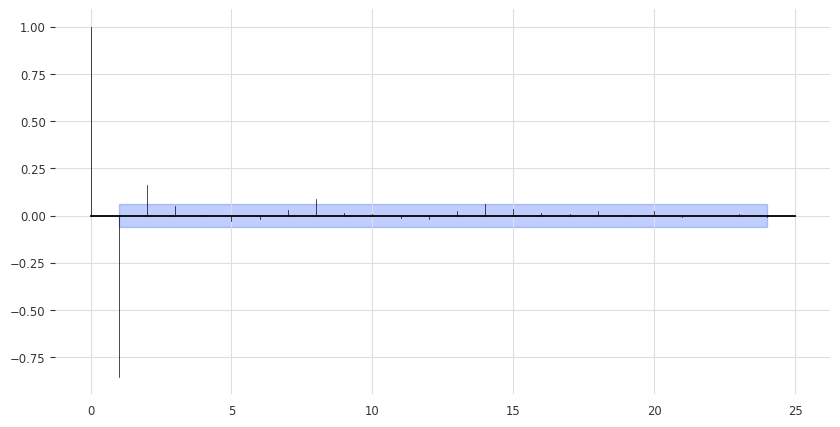

In [32]:
from darts.utils.statistics import plot_pacf

plot_pacf(simulated_series_darts_ar2)
#La grafica nos da valores consistentes con las simulaciones, el primero es 1, el segundo fue -0.75(cercano a 7) y finalmente 0.2 (positivo)

In [33]:
from darts.models import ARIMA
model = ARIMA(p=2, d=0, q=0)
model.fit(simulated_series_darts_ar2)

ARIMA(p=2, d=0, q=0, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

In [34]:
underlying_model = model.model

# Obtener y mostrar los parámetros estimados
estimated_params = underlying_model.params
print(estimated_params)
#orden
#-0.31 Intercepto (constante): 
#Es el promedio o “nivel base” alrededor del cual oscila la serie. En este caso, está muy cerca de 0 → la serie está centrada.
#-0.71 Coeficiente 𝜙1: lo ajustado en el arreglo [-, 0.7,-] (cambio de signo)
#0.16 Coeficiente 𝜙2: lo ajustado en el arreglo [-,-, -0.2] (cambio de signo)
#0.96 σ (desviación estándar del error):Mide la magnitud promedio del “ruido” o variabilidad no explicada por el modelo.

[-0.03087895 -0.71523828  0.16174665  0.96962392]
